# 🔧 Car Price Prediction — Notebook 2: Feature Engineering

---

## 📌 Introduction

We prepare the dataset for ML training:

1. Drop `name` (463 unique values, redundant)
2. Create `car_age = 2024 − year`
3. **Log-transform `Price`** — fixes right skew, reduces RMSE
4. One-hot encode `company` and `fuel_type`
5. Train-Test Split (80/20)
6. Scale numerical features
7. Save all artifacts

---
## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle, os, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Libraries imported!')

Libraries imported!


---
## 📂 Step 2: Load Dataset

In [2]:
df = pd.read_csv('../data/cleaned_car.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (725, 6)


,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel


---
## 🗂️ Step 3: Drop `name`

In [3]:
df = df.drop(columns=['name'])
print(f'Columns remaining: {df.columns.tolist()}')

Columns remaining: ['company', 'year', 'Price', 'kms_driven', 'fuel_type']


---
## 🔨 Step 4: Create `car_age` from `year`

`car_age = 2024 − year` directly encodes how long the car has been depreciating.
A 2010 car is always 14 years old — more intuitive than a raw timestamp.

In [4]:
REFERENCE_YEAR = 2024
df['car_age'] = REFERENCE_YEAR - df['year']
df = df.drop(columns=['year'])

print(f'car_age range: {df["car_age"].min()} – {df["car_age"].max()} years')
print(f'Correlation (car_age vs Price): {df["car_age"].corr(df["Price"]):.4f}')

car_age range: 5 – 29 years
Correlation (car_age vs Price): -0.3640


---
## 📐 Step 5: Log-Transform the Target Variable (`Price`)

### Why is the raw Price problematic?

Our target variable is **heavily right-skewed**:

```
Skewness of Price ≈ 2.97   (anything > 1 is considered heavily skewed)
Mean   ≈ ₹3,92,000
Median ≈ ₹2,90,000
Range  ≈ ₹30,000 – ₹31,00,000
```

The gap between mean and median, and the enormous range, tells us most cars are cheap but a
few luxury cars are extremely expensive. This is a classic **long right tail**.

### What does skewness do to the model?

**For Linear Regression:**
The model tries to minimise squared errors. A luxury car priced at ₹31 lakh that the model
predicts as ₹15 lakh creates a squared error of ₹(16L)² = ₹256 trillion. This one data point
pulls the regression line far from where most of the data lives. The model ends up making
mediocre predictions for the majority of cheap cars just to reduce error on rare expensive ones.

**Real-world analogy:**
Imagine teaching a student the "average height" using 99 adults and 1 NBA player. The average
gets pulled toward the NBA player's height, giving bad estimates for everyone else.

### What does log-transform fix?

```python
log_price = np.log(price)
```

Taking log compresses the long right tail:
```
log(30,000)    = 10.31
log(3,00,000)  = 12.61
log(31,00,000) = 14.95
```

The transformed values span 10.3 – 15.0 — a tight, nearly symmetric range.
Skewness drops from **2.97 → -0.04** (essentially zero).

### The improvement is predictable:

| Without log | With log |
|-------------|----------|
| Model fights outliers | Outliers are compressed |
| High RMSE on luxury cars | More balanced errors across all price segments |
| Skewed residuals | Nearly normal residuals (Linear Regression assumption met) |

### How do we use it?

- **Training**: fit model on `log(Price)`
- **Prediction**: call `np.exp()` to convert back to original ₹ scale
- All evaluation metrics (MAE, RMSE, R²) are computed on the **original price scale** after back-transformation

### What happens if we skip this?

The model still works but makes systematically larger errors on mid-range cars (the majority)
because it's being dragged by luxury outliers. RMSE stays high.

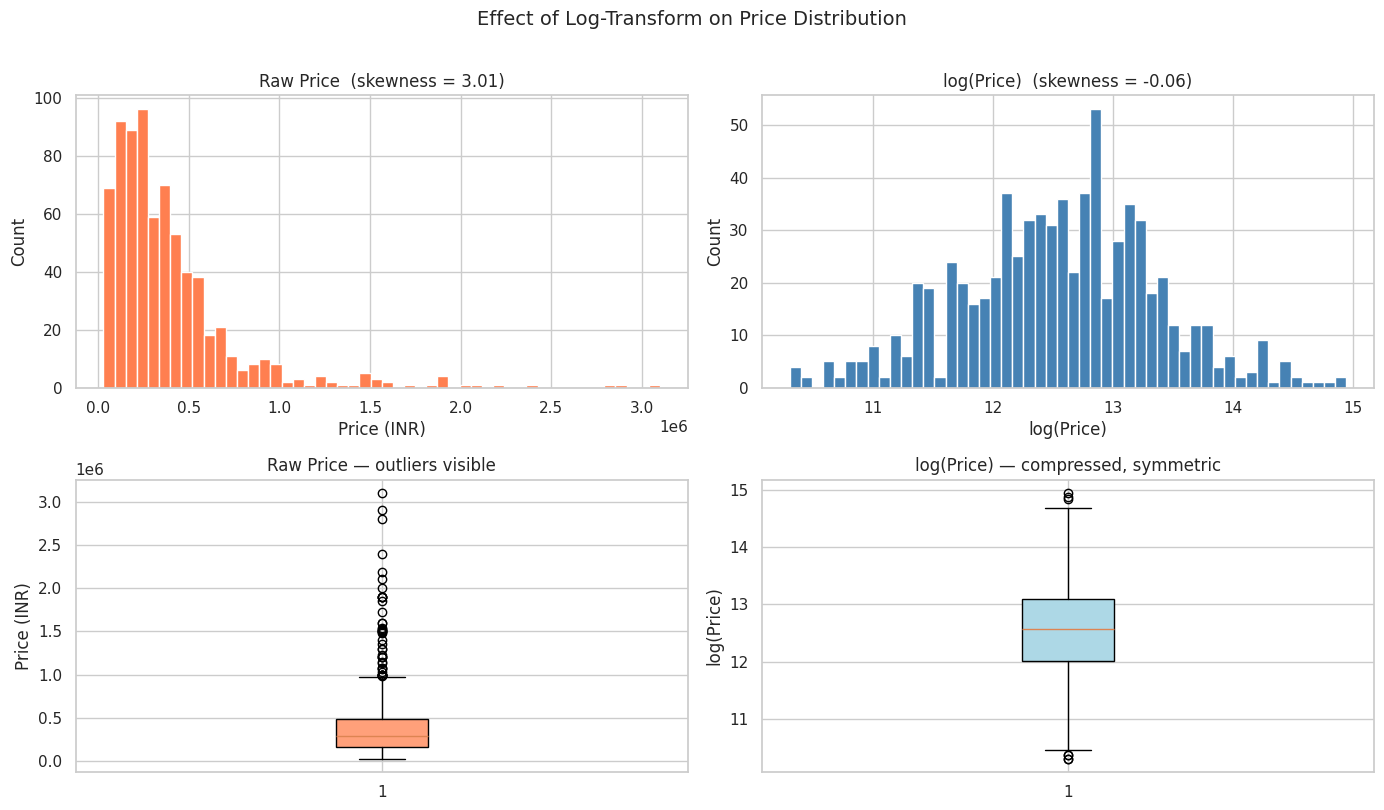

Raw Price  — Mean: ₹392,516  Median: ₹290,000  Skewness: 3.01
log(Price) — Mean: 12.55       Median: 12.58       Skewness: -0.06


In [5]:
# Visualise the problem: raw Price vs log(Price)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Raw price histogram
axes[0, 0].hist(df['Price'], bins=50, color='coral', edgecolor='white')
axes[0, 0].set_title(f'Raw Price  (skewness = {df["Price"].skew():.2f})')
axes[0, 0].set_xlabel('Price (INR)')
axes[0, 0].set_ylabel('Count')

# Log price histogram
log_price = np.log(df['Price'])
axes[0, 1].hist(log_price, bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title(f'log(Price)  (skewness = {log_price.skew():.2f})')
axes[0, 1].set_xlabel('log(Price)')
axes[0, 1].set_ylabel('Count')

# Raw price box plot
axes[1, 0].boxplot(df['Price'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightsalmon'))
axes[1, 0].set_title('Raw Price — outliers visible')
axes[1, 0].set_ylabel('Price (INR)')

# Log price box plot
axes[1, 1].boxplot(log_price, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
axes[1, 1].set_title('log(Price) — compressed, symmetric')
axes[1, 1].set_ylabel('log(Price)')

plt.suptitle('Effect of Log-Transform on Price Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'Raw Price  — Mean: ₹{df["Price"].mean():,.0f}  Median: ₹{df["Price"].median():,.0f}  Skewness: {df["Price"].skew():.2f}')
print(f'log(Price) — Mean: {log_price.mean():.2f}       Median: {log_price.median():.2f}       Skewness: {log_price.skew():.2f}')

In [6]:
# Apply the log transform — this becomes our new target variable
df['log_price'] = np.log(df['Price'])

print('Created log_price column.')
print(f'log_price range: {df["log_price"].min():.2f} – {df["log_price"].max():.2f}')
print()
print('Side-by-side comparison (first 5 rows):')
print(df[['Price', 'log_price']].head().to_string(index=False))

Created log_price column.
log_price range: 10.31 – 14.95

Side-by-side comparison (first 5 rows):
 Price  log_price
 80000  11.289782
425000  12.959844
325000  12.691580
575000  13.262125
175000  12.072541


---
## ❓ Step 6: Missing Value Check

In [7]:
print(df.isnull().sum())
print(f'Total missing: {df.isnull().sum().sum()}')

company       0
Price         0
kms_driven    0
fuel_type     0
car_age       0
log_price     0
dtype: int64
Total missing: 0


---
## 🔤 Step 7: One-Hot Encoding

Both `fuel_type` (Petrol/Diesel/LPG) and `company` (25 brands) are **nominal categories** —
no natural ordering → One-Hot Encoding for both.

In [8]:
df = pd.get_dummies(df, columns=['fuel_type', 'company'], drop_first=False)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
print(f'Shape after encoding: {df.shape}')
df.head(2)

Shape after encoding: (725, 32)


,Price,kms_driven,car_age,log_price,fuel_type_Diesel,fuel_type_LPG,fuel_type_Petrol,company_Audi,company_BMW,company_Chevrolet,...,company_Mercedes,company_Mini,company_Mitsubishi,company_Nissan,company_Renault,company_Skoda,company_Tata,company_Toyota,company_Volkswagen,company_Volvo
0,80000,45000,17,11.289782,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,425000,40,18,12.959844,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


---
## ✂️ Step 8: Separate Features and Target

In [9]:
# We use log_price as the target (not raw Price)
X = df.drop(columns=['Price', 'log_price'])
y = df['log_price']                          # ← log-transformed target
y_original = df['Price']                     # ← keep original for reference

print(f'X shape        : {X.shape}')
print(f'y (log_price)  : min={y.min():.2f}, max={y.max():.2f}')
print(f'y (orig Price) : min=₹{np.exp(y.min()):,.0f}, max=₹{np.exp(y.max()):,.0f}')
print(f'\nFeature columns: {X.columns.tolist()}')

X shape        : (725, 30)
y (log_price)  : min=10.31, max=14.95
y (orig Price) : min=₹30,000, max=₹3,100,000

Feature columns: ['kms_driven', 'car_age', 'fuel_type_Diesel', 'fuel_type_LPG', 'fuel_type_Petrol', 'company_Audi', 'company_BMW', 'company_Chevrolet', 'company_Datsun', 'company_Fiat', 'company_Force', 'company_Ford', 'company_Hindustan', 'company_Honda', 'company_Hyundai', 'company_Jaguar', 'company_Jeep', 'company_Land', 'company_Mahindra', 'company_Maruti', 'company_Mercedes', 'company_Mini', 'company_Mitsubishi', 'company_Nissan', 'company_Renault', 'company_Skoda', 'company_Tata', 'company_Toyota', 'company_Volkswagen', 'company_Volvo']


---
## ✂️ Step 9: Train-Test Split

**Important:** we split both `y` (log scale) and `y_original` (INR scale) using the
**same indices** so we can evaluate predictions on the original price scale.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, y_orig_train, y_orig_test = train_test_split(
    X, y, y_original, test_size=0.20, random_state=42)

print(f'Training : {X_train.shape[0]} rows')
print(f'Testing  : {X_test.shape[0]} rows')
print()
print('y_train is in log scale  — model trains on this')
print('y_orig_test is in INR    — we evaluate predictions on this')

Training : 580 rows
Testing  : 145 rows

y_train is in log scale  — model trains on this
y_orig_test is in INR    — we evaluate predictions on this


---
## 📏 Step 10: Feature Scaling

Scale `car_age` and `kms_driven` to zero-mean, unit-variance.
**Fit on training data only** to prevent data leakage.

In [11]:
scaler = StandardScaler()
num_cols = ['car_age', 'kms_driven']

scaler.fit(X_train[num_cols])
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f'Scaler mean  — car_age: {scaler.mean_[0]:.2f} yr, kms_driven: {scaler.mean_[1]:.0f} km')
print(f'After scaling — mean ≈ 0, std ≈ 1:')
print(X_train[num_cols].describe().round(3).to_string())

Scaler mean  — car_age: 11.77 yr, kms_driven: 46599 km
After scaling — mean ≈ 0, std ≈ 1:
       car_age  kms_driven
count  580.000     580.000
mean     0.000       0.000
std      1.001       1.001
min     -1.619      -1.464
25%     -0.663      -0.567
50%     -0.185      -0.145
75%      0.532       0.379
max      4.117       4.821


---
## 💾 Step 11: Save All Artifacts

In [12]:
os.makedirs('../artifacts', exist_ok=True)

feature_columns = X_train.columns.tolist()
company_list  = sorted([c.replace('company_','')   for c in feature_columns if c.startswith('company_')])
fuel_list     = sorted([c.replace('fuel_type_','') for c in feature_columns if c.startswith('fuel_type_')])
encoder_data  = {'company_list': company_list, 'fuel_type_list': fuel_list}

with open('../artifacts/scaler.pkl',  'wb') as f: pickle.dump(scaler, f)
with open('../artifacts/columns.pkl', 'wb') as f: pickle.dump(feature_columns, f)
with open('../artifacts/encoder.pkl', 'wb') as f: pickle.dump(encoder_data, f)

# Save processed data for Notebook 3
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv',   index=False)
y_train.to_csv('../data/y_train.csv', index=False)          # log scale
y_test.to_csv('../data/y_test.csv',   index=False)           # log scale
y_orig_test.to_csv('../data/y_orig_test.csv', index=False)  # INR scale — for evaluation

print('Artifacts saved:')
print(f'  scaler.pkl  — StandardScaler on car_age & kms_driven')
print(f'  columns.pkl — {len(feature_columns)} features')
print(f'  encoder.pkl — {len(company_list)} companies, {len(fuel_list)} fuel types')
print()
print('NOTE: y_train.csv contains log(Price). Notebook 3 must call np.exp() on predictions.')

Artifacts saved:
  scaler.pkl  — StandardScaler on car_age & kms_driven
  columns.pkl — 30 features
  encoder.pkl — 25 companies, 3 fuel types

NOTE: y_train.csv contains log(Price). Notebook 3 must call np.exp() on predictions.


---
## 📋 Summary

| Step | Action | Key Reason |
|------|--------|-----------|
| Drop `name` | Removed | 463 unique values, redundant |
| `car_age = 2024 − year` | Created | Direct depreciation signal |
| **`log(Price)` as target** | **Applied** | **Skewness 2.97 → −0.04; RMSE improves; LR assumptions met** |
| One-Hot encode | `company` (25) + `fuel_type` (3) | Nominal categories |
| StandardScaler | `car_age`, `kms_driven` | Normalise magnitude |
| 80/20 split | random_state=42 | Reproducible evaluation |

**Features:** 30 columns | **Train:** 580 | **Test:** 145 | **Target:** log(Price)

---
## 🎯 Interview Questions

**Q1. When should you log-transform the target variable?**
> When the target is right-skewed (skewness > 1). Log-transform compresses the long tail, making errors more symmetric and reducing the influence of extreme values on linear models. It also satisfies the normality-of-residuals assumption that Linear Regression makes.

**Q2. After predicting log(Price), how do you get the actual price?**
> Apply `np.exp(predicted_log_price)`. Since `log` and `exp` are inverse functions: `exp(log(x)) = x`. Never forget this step — predicting log(₹2.9L) = 12.58, but the user needs to see ₹2,90,000.

**Q3. Why does log-transform help Linear Regression more than tree models?**
> Linear Regression assumes residuals are normally distributed and equally spread across all prediction ranges (homoscedasticity). A skewed target violates both. Trees make no distributional assumption — they split on rank-based thresholds, so they handle skew better. However, when you exp() back a tree's predictions, variance amplification can sometimes hurt overall RMSE.

**Q4. Can you always apply log-transform? What's the limitation?**
> Only works for strictly positive values — `log(0)` is undefined and `log(negative)` is not real. If the target includes zeros or negatives, use `np.log1p(x)` (which computes log(1+x)), or apply a Yeo-Johnson transform instead.

**Q5. What is the practical ceiling of this model, and why?**
> Around R²=0.73 with this dataset. The remaining 27% of price variance comes from features not collected: car condition (biggest factor), trim/variant, number of previous owners, service history, and geographic location. This is a data limitation, not a modelling limitation — no algorithm can learn what the data doesn't contain.

---
## ❌ Common Mistakes

1. **Forgetting to exp() predictions** — The model returns log(Price). Without exp(), you report values like 12.6 instead of ₹2,90,000.
2. **Applying log to the features instead of the target** — Both can be valid, but log(Price) is what directly fixes the skewed target problem.
3. **Using log1p on Price** — `log1p` is for values that include zero. Since Price is always > 0 here, plain `np.log` is correct and slightly more interpretable.
4. **Evaluating RMSE on the log scale** — Always convert predictions back to INR before computing MAE/RMSE. Log-scale metrics are meaningless to stakeholders.